# DDS Model – Sensitivity Analysis

This notebook performs a **parameter sensitivity analysis** for the Dual Damped Sine (DDS) model used to characterize early TMS-evoked EEG potentials (TEPs).

We explore how small changes (±20%) in each DDS parameter affect the modeled waveform, providing visual and quantitative insights into:

- **Amplitude components**: A1, A2  
- **Frequencies**: f1, f2  
- **Damping factors**: γ1, γ2  
- (Optional: offset and onset `t0`)

This type of analysis helps assess the **identifiability** and **interpretability** of the model parameters and their physiological plausibility.

---

### Model equation

The DDS model expresses a TEP as:

y(t) = A₁·e^(−γ₁·t)·sin(2π·f₁·t + φ₁) + A₂·e^(−γ₂·t)·sin(2π·f₂·t + φ₂) + offset 


Each component is gated with a **Heaviside step function** starting at `t0`.

---

### Reference

This analysis supports the manuscript:

> **Damián Jan (2025)**. *A Dual Damped Sine (DDS) model for TMS–EEG: parametric validation against cosine similarity on OpenNeuro ds001849*. *Journal of Neuroscience Methods* (submitted).

For methodological background, see also:

> **Freedberg et al., 2020**, *PLoS ONE*, 15(1): e0216185.  
> [https://doi.org/10.1371/journal.pone.0216185](https://doi.org/10.1371/journal.pone.0216185)

---

### Requirements

- numpy, matplotlib
- (optional) seaborn for enhanced plots

---

### Contact & License

Developed by **Damián Jan**  
📧 damian.jan@dejsl.com  
📝 License: MIT (or specify your preferred license)


In [5]:

# === Publication-quality preset (journal-neutral) ===
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

mpl.rcParams.update({
    "figure.figsize": (7.0, 4.2),   # single-column default
    "figure.dpi": 150,              # inline preview
    "savefig.dpi": 600,             # exported images
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.01,

    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,

    "lines.linewidth": 1.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",         # keep text as text in SVG
    "figure.constrained_layout.use": True,
})

# Optional: smoother joins/caps without changing color/style
def _roundify_lines(ax=None):
    ax = ax or plt.gca()
    for ln in getattr(ax, "lines", []):
        ln.set_solid_joinstyle("round")
        ln.set_solid_capstyle("round")

# Save only PNG (600 dpi by default), no recursion
from pathlib import Path
import matplotlib.pyplot as plt

def save_png(path_like, dpi=600, bbox_inches="tight", pad_inches=0.01):
    p = Path(path_like)
    # ensure .png suffix
    if p.suffix.lower() != ".png":
        p = p.with_suffix(".png")
    plt.savefig(p, dpi=dpi, bbox_inches=bbox_inches, pad_inches=pad_inches)
    print("Saved:", p)

# Improve inline rendering (no effect on saved files)
try:
    from IPython import get_ipython
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')
except Exception:
    pass


/tmp/ipykernel_337711/2970493362.py:68: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 0.95, 0.95])


Saved: DDS_parameter_sensitivity.png


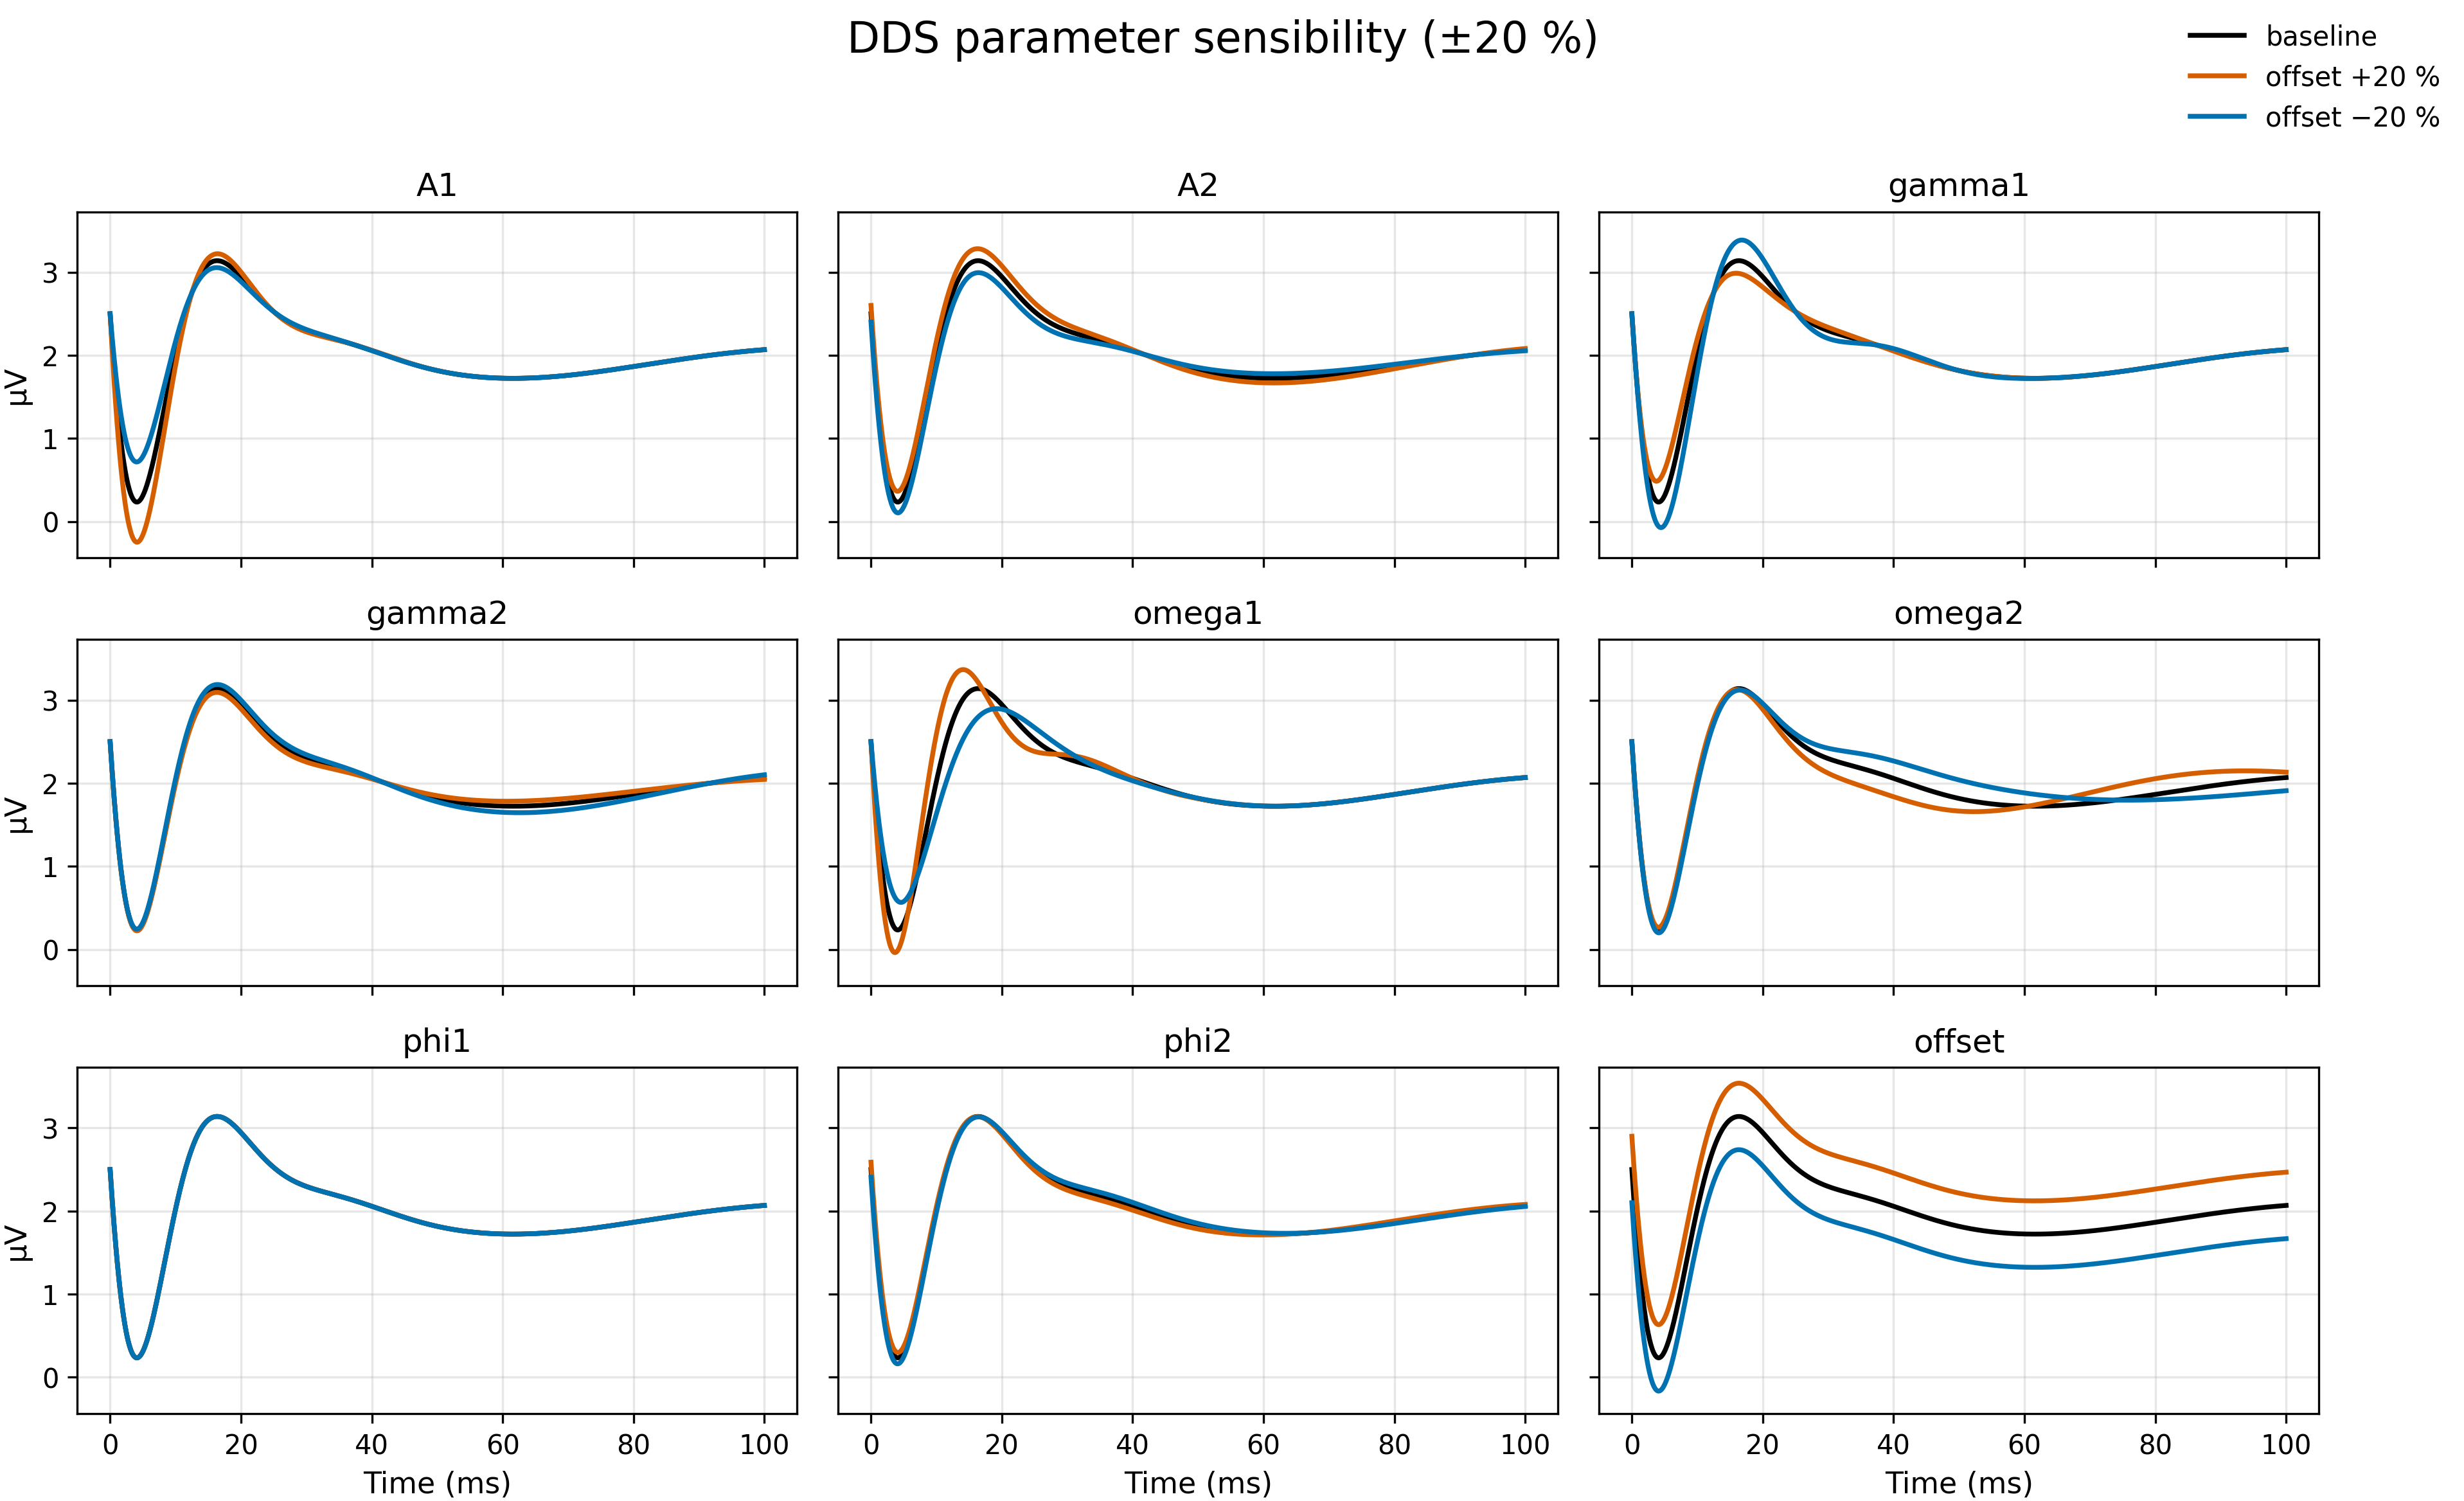

In [6]:
#!/usr/bin/env python3
# DDS sensitivity plot
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Modelo DDS (damped-dual-sine)
def dds(t, A1, A2, gamma1, gamma2, omega1, omega2, phi1, phi2, offset):
    term1 = A1 * np.exp(-gamma1 * t) * np.sin(omega1 * t + phi1)
    term2 = A2 * np.exp(-gamma2 * t) * np.sin(omega2 * t + phi2)
    return term1 + term2 + offset

# 2. Parámetros baseline (puedes ajustarlos a tu rango típico)
base_params = dict(
    A1=-5.0,      # µV
    A2=1.0,
    gamma1=140.0,  # s⁻¹
    gamma2=20.0,
    omega1=2*np.pi*40,   # rad/s  (≈40 Hz)
    omega2=2*np.pi*10,   # rad/s  (≈10 Hz)
    phi1=0.0,
    phi2=np.pi/6,
    offset=2.0
)

# 3. Configuración para variar ±20 %
VAR_FACTOR = 0.20   # 20 %
colors = {"down": "#0072B2", "base": "k", "up": "#D55E00"}

# 4. Cronograma
t = np.linspace(0, 0.1, 1000)   # 0-100 ms con 0.1 ms de resolución

# 5. Preparar figura
param_names = list(base_params.keys())
n_cols = 3
n_rows = int(np.ceil(len(param_names) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 8), sharex=True, sharey=True)
axes = axes.flatten()

# 6. Recorrer parámetros y dibujar curvas
for i, p in enumerate(param_names):
    ax = axes[i]
    # baseline
    y_base = dds(t, **base_params)
    ax.plot(t*1000, y_base, color=colors["base"], label="baseline")
    
    # parámetro +20 %
    params_up   = base_params.copy();  params_up[p] *= (1 + VAR_FACTOR)
    y_up = dds(t, **params_up)
    ax.plot(t*1000, y_up, color=colors["up"],   label=f"{p} +20 %")
    
    # parámetro −20 %
    params_down = base_params.copy();  params_down[p] *= (1 - VAR_FACTOR)
    y_down = dds(t, **params_down)
    ax.plot(t*1000, y_down, color=colors["down"], label=f"{p} −20 %")
    
    ax.set_title(p)
    ax.grid(alpha=0.3)
    if i % n_cols == 0:
        ax.set_ylabel("µV")
    if i >= (n_rows-1)*n_cols:
        ax.set_xlabel("Time (ms)")

# 7. Ajustes finales
fig.suptitle("DDS parameter sensibility (±20 %)", fontsize=16)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", frameon=False)
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
save_png("DDS_parameter_sensitivity.png", )
plt.show()
